In [4]:
import pandas as pd

# ── Constant USD sheet ──────────────────────────────────────
const = pd.read_excel(
    "/Users/naman/Code/defense_analyst/data/raw/sipri_milex.xlsx",
    sheet_name="Constant (2024) US$",
    skiprows=5,        # SIPRI has 5 header rows before actual data
    index_col=0
)

# Drop empty rows and columns
const = const.dropna(how="all").dropna(axis=1, how="all")

# Filter only our 3 countries
countries = ["India", "China", "Pakistan"]
const_filtered = const[const.index.isin(countries)]

const_filtered.to_csv("/Users/naman/Code/defense_analyst/data/raw/sipri_milex_constant_usd.csv")
print("Constant USD shape:", const_filtered.shape)
print(const_filtered)


# ── Share of GDP sheet ──────────────────────────────────────
gdp = pd.read_excel(
    "/Users/naman/Code/defense_analyst/data/raw/sipri_milex.xlsx",
    sheet_name="Share of GDP",
    skiprows=5,
    index_col=0
)

gdp = gdp.dropna(how="all").dropna(axis=1, how="all")
gdp_filtered = gdp[gdp.index.isin(countries)]

gdp_filtered.to_csv("/Users/naman/Code/defense_analyst/data/raw/sipri_milex_gdp_share.csv")
print("\nGDP Share shape:", gdp_filtered.shape)
print(gdp_filtered)

Constant USD shape: (3, 78)
         Notes 1949 1950 1951 1952 1953 1954 1955         1956         1957  \
Country                                                                       
India       59  ...  ...  ...  ...  ...  ...  ...  3046.047477  3642.851291   
Pakistan    60  ...  ...  ...  ...  ...  ...  ...   629.677604   522.599357   
China       55  ...  ...  ...  ...  ...  ...  ...          ...          ...   

          ...           2016           2017           2018           2019  \
Country   ...                                                               
India     ...   67201.659538    71935.62091   74468.863512   79726.147691   
Pakistan  ...    9656.453407   10584.574451   11837.861864   11693.744418   
China     ...  207375.409988  220129.319922  233023.664267  244375.956199   

                   2020           2021           2022           2023  \
Country                                                                
India      80209.725917   79701.317304   83218

In [2]:
import os
os.chdir("/Users/naman/Code/DefDex")
print(os.getcwd())  # should print /Users/naman/Code/DefDex

/Users/naman/Code/DefDex


In [6]:
# Run this as a separate cell first
import pandas as pd
gfp_check = pd.read_csv("data/raw/gfp_raw.csv")
print(gfp_check.head())
print("\nColumns:", gfp_check.columns.tolist())

              metric         india         china     pakistan
0        power_index  1.286000e-01  7.060000e-02       0.2513
1   active_personnel  1.450000e+06  2.000000e+06  654000.0000
2  reserve_personnel  1.155000e+06  5.100000e+05  550000.0000
3     total_aircraft  2.229000e+03  3.304000e+03    1372.0000
4    combat_aircraft  6.060000e+02  1.900000e+03     425.0000

Columns: ['metric', 'india', 'china', 'pakistan']


In [10]:
# ── UCDP: filter interstate wars only ───────────────────────
interstate = ucdp[ucdp["type_of_conflict"] == 2].copy()
print("\nInterstate wars in dataset:", len(interstate))

# intensity_level replaces outcome in newer UCDP versions
# 1 = minor conflict (25-999 deaths), 2 = war (1000+ deaths)
print("\nIntensity distribution:\n", interstate["intensity_level"].value_counts())
print("\nRegion distribution:\n", interstate["region"].value_counts())

# Check if India, China, Pakistan appear
for country in ["India", "China", "Pakistan"]:
    mask = interstate["side_a"].str.contains(country, na=False) | \
           interstate["side_b"].str.contains(country, na=False)
    print(f"\n{country} conflicts: {mask.sum()}")
    print(interstate[mask][["year","side_a","side_b","intensity_level"]].to_string())


Interstate wars in dataset: 147

Intensity distribution:
 intensity_level
1    90
2    57
Name: count, dtype: int64

Region distribution:
 region
3             78
2             30
4             16
1              5
5              5
1, 3           4
1, 2           4
1, 3, 5        1
1, 2, 5        1
1, 4           1
1, 5           1
1, 2, 3, 5     1
Name: count, dtype: int64

India conflicts: 31
      year                   side_a                  side_b  intensity_level
405   1948      Government of India  Government of Pakistan                2
406   1964      Government of India  Government of Pakistan                1
407   1965      Government of India  Government of Pakistan                2
408   1971      Government of India  Government of Pakistan                2
409   1984      Government of India  Government of Pakistan                1
410   1987      Government of India  Government of Pakistan                1
411   1989      Government of India  Government of Pakistan    

In [11]:
# ── Full conflict summary for our 3 countries ───────────────
for country in ["India", "China", "Pakistan"]:
    mask = interstate["side_a"].str.contains(country, na=False) | \
           interstate["side_b"].str.contains(country, na=False)
    conflicts = interstate[mask]
    print(f"\n{'='*40}")
    print(f"{country} — total conflict episodes: {len(conflicts)}")
    print(f"Minor (intensity 1): {len(conflicts[conflicts['intensity_level']==1])}")
    print(f"War level (intensity 2): {len(conflicts[conflicts['intensity_level']==2])}")
    print(f"Year range: {conflicts['year'].min()} — {conflicts['year'].max()}")


India — total conflict episodes: 31
Minor (intensity 1): 26
War level (intensity 2): 5
Year range: 1948 — 2020

China — total conflict episodes: 19
Minor (intensity 1): 14
War level (intensity 2): 5
Year range: 1949 — 2020

Pakistan — total conflict episodes: 28
Minor (intensity 1): 25
War level (intensity 2): 3
Year range: 1948 — 2024


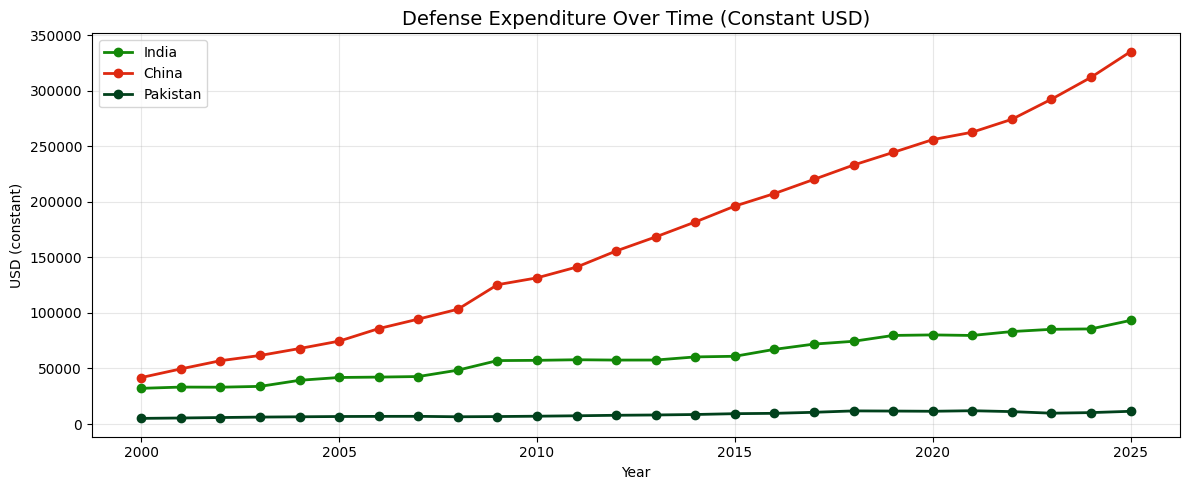

✅ Plot saved


In [12]:
# ── Plot: defense spend over time ───────────────────────────
years = [col for col in sipri_const.columns if str(col).strip().isdigit()]
sipri_plot = sipri_const[years].T
sipri_plot.columns = sipri_const.index
sipri_plot.index = sipri_plot.index.astype(int)
sipri_plot = sipri_plot[sipri_plot.index >= 2000]

plt.figure(figsize=(12, 5))
colors = {"India": "#138808", "China": "#DE2910", "Pakistan": "#01411C"}
for country in ["India", "China", "Pakistan"]:
    if country in sipri_plot.columns:
        plt.plot(sipri_plot.index, sipri_plot[country],
                marker="o", label=country,
                color=colors[country], linewidth=2)

plt.title("Defense Expenditure Over Time (Constant USD)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("USD (constant)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("notebooks/defense_spend_trend.png", dpi=150)
plt.show()
print("✅ Plot saved")

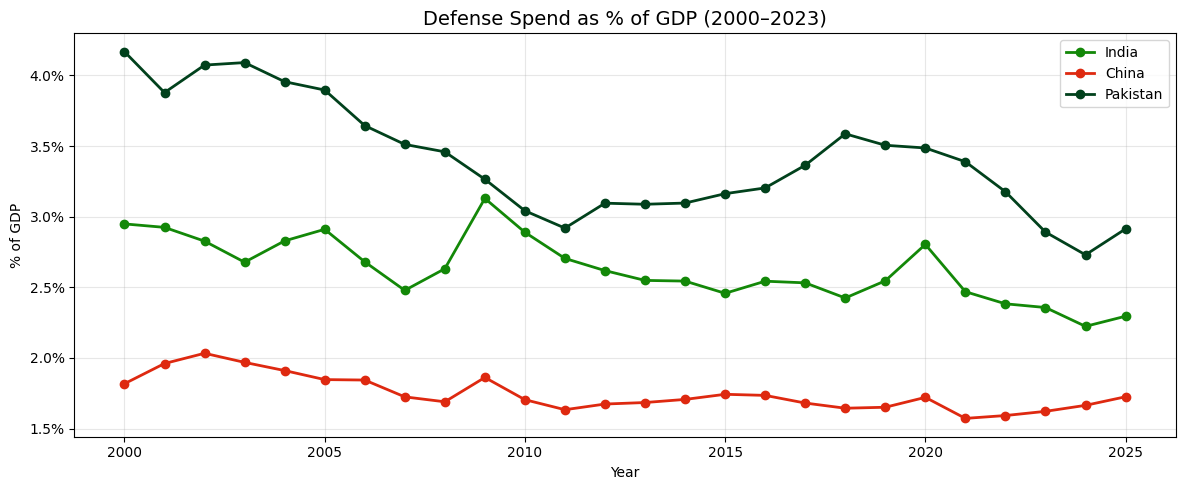

✅ Plot saved to notebooks/defense_gdp_share.png


In [14]:
# ── Plot: defense spend as % of GDP ─────────────────────────
years = [col for col in sipri_gdp.columns if str(col).strip().isdigit()]

sipri_gdp_plot = sipri_gdp[years].T
sipri_gdp_plot.columns = sipri_gdp.index
sipri_gdp_plot.index = sipri_gdp_plot.index.astype(int)
sipri_gdp_plot = sipri_gdp_plot[sipri_gdp_plot.index >= 2000]

plt.figure(figsize=(12, 5))
colors = {"India": "#138808", "China": "#DE2910", "Pakistan": "#01411C"}
for country in ["India", "China", "Pakistan"]:
    if country in sipri_gdp_plot.columns:
        plt.plot(sipri_gdp_plot.index, sipri_gdp_plot[country],
                marker="o", label=country,
                color=colors[country], linewidth=2)

plt.title("Defense Spend as % of GDP (2000–2023)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("notebooks/defense_gdp_share.png", dpi=150)
plt.gca().yaxis.set_major_formatter(
plt.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
plt.show()
print("✅ Plot saved to notebooks/defense_gdp_share.png")